# HYBRID IR: BM25 + LDA — Grid Search (alpha, k) và sweep n_topics

**LDA = mô hình chủ đề xác suất (Latent Dirichlet Allocation):** mỗi tài liệu là phân phối trên K chủ đề; mỗi chủ đề là phân phối trên từ vựng.

Cùng framework đánh giá với `lsa.ipynb` và `lsi.ipynb`:
- 20k tài liệu VietNews
- 15 test queries chung
- Grid α × k × n_topics
- 6 metrics: P, R, F1, MAP, MRR, NDCG

## 1. CÀI ĐẶT THƯ VIỆN

In [1]:
!pip install rank_bm25 datasets pyvi -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.5/8.5 MB 32.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 15.3 MB/s eta 0:00:00


In [2]:
import os
import re
import time
import zipfile
import warnings

import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt
import seaborn as sns

from datasets import load_dataset
from pyvi import ViTokenizer
from rank_bm25 import BM25Okapi
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.preprocessing import normalize

warnings.filterwarnings('ignore')
plt.rcParams['font.sans-serif'] = ['DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False
sns.set_style('whitegrid')

## 2. CẤU HÌNH CHUNG (dùng giống nhau cho LSA / LSI / LDA)

In [3]:
MAX_SAMPLES      = 20000
RANDOM_STATE     = 42
ALPHA_GRID       = [0.0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0]
K_GRID           = [1, 3, 5, 10, 20]
N_TOPICS_GRID    = [10, 20, 50, 100]
DEFAULT_K        = 10
DEFAULT_N_TOPICS = 50
LDA_MAX_ITER     = 10
MODEL_NAME       = 'lda'

TEST_QUERIES = [
    {'query': 'thời tiết mưa bão nhiệt độ dự báo',     'category': 'weather',       'keywords': ['thời tiết', 'mưa', 'bão', 'nhiệt độ', 'dự báo']},
    {'query': 'chứng khoán cổ phiếu thị trường đầu tư', 'category': 'stock',         'keywords': ['chứng khoán', 'cổ phiếu', 'thị trường', 'đầu tư']},
    {'query': 'bóng đá việt nam cầu thủ đội tuyển',     'category': 'sports',        'keywords': ['bóng đá', 'việt nam', 'cầu thủ', 'đội tuyển']},
    {'query': 'công nghệ AI trí tuệ nhân tạo máy học',  'category': 'tech',          'keywords': ['công nghệ', 'ai', 'trí tuệ', 'nhân tạo', 'máy học']},
    {'query': 'giá vàng hôm nay tăng mạnh',             'category': 'commodity',     'keywords': ['vàng', 'giá', 'tăng', 'thị trường']},
    {'query': 'dịch covid vaccine tiêm chủng',          'category': 'health',        'keywords': ['covid', 'vaccine', 'dịch', 'bệnh']},
    {'query': 'xe điện vinfast ô tô sản xuất',          'category': 'automotive',    'keywords': ['xe điện', 'vinfast', 'ô tô', 'sản xuất']},
    {'query': 'ca sĩ nhạc mới album âm nhạc',           'category': 'entertainment', 'keywords': ['ca sĩ', 'nhạc', 'album', 'âm nhạc']},
    {'query': 'tội phạm ma túy bắt giữ',                'category': 'crime',         'keywords': ['ma túy', 'tội phạm', 'bắt', 'giữ']},
    {'query': 'tai nạn giao thông xe hỏng',             'category': 'accident',      'keywords': ['tai nạn', 'giao thông', 'xe', 'hỏng']},
    {'query': 'thể thao olympic vàng huy chương',       'category': 'olympic',       'keywords': ['thể thao', 'olympic', 'vàng', 'huy chương']},
    {'query': 'du lịch resort khách sạn nghỉ dưỡng',    'category': 'travel',        'keywords': ['du lịch', 'resort', 'khách sạn', 'nghỉ dưỡng']},
    {'query': 'giáo dục trường học sinh viên',          'category': 'education',     'keywords': ['giáo dục', 'trường', 'học', 'sinh viên']},
    {'query': 'chính trị quốc tế tổng thống',           'category': 'politics',      'keywords': ['chính trị', 'quốc tế', 'tổng thống', 'chính phủ']},
    {'query': 'thời trang làm đẹp con gái',             'category': 'fashion',       'keywords': ['thời trang', 'làm đẹp', 'con gái', 'mỹ phẩm']},
]

np.random.seed(RANDOM_STATE)
print(f'Config: MODEL={MODEL_NAME} | N={MAX_SAMPLES} | |alpha|={len(ALPHA_GRID)} | |k|={len(K_GRID)} | |n_topics|={len(N_TOPICS_GRID)} | |Q|={len(TEST_QUERIES)}')

Config: MODEL=lda | N=20000 | |alpha|=11 | |k|=5 | |n_topics|=4 | |Q|=15


## 3. TIỀN XỬ LÝ TIẾNG VIỆT

In [4]:
STOPWORDS = set([
    'và', 'của', 'một', 'những', 'các', 'được', 'có', 'là', 'cho', 'khi',
    'đã', 'sẽ', 'nếu', 'như', 'tại', 'vào', 'ra', 'mà', 'này', 'kia', 'đó',
    'ấy', 'thì', 'rằng', 'để', 'với', 'không', 'cũng', 'lại', 'rất', 'nên',
    'bị', 'do', 'về', 'theo', 'qua', 'trong', 'ngoài', 'trên', 'dưới', 'bởi',
    'cả', 'cùng', 'đang', 'đây', 'đến', 'đi', 'hơn', 'kể', 'lên', 'mới',
    'ngay', 'nữa', 'rồi', 'sau', 'thôi', 'thưa'
])
VI_CHARS = (
    'a-z0-9'
    'àáạảãâầấậẩẫăằắặẳẵ'
    'èéẹẻẽêềếệểễ'
    'ìíịỉĩ'
    'òóọỏõôồốộổỗơờớợởỡ'
    'ùúụủũưừứựửữ'
    'ỳýỵỷỹđ'
)
_RE_HTML  = re.compile(r'<[^>]+>')
_RE_URL   = re.compile(r'http\S+|www\S+|https\S+')
_RE_CHARS = re.compile(rf'[^{VI_CHARS}\s_]')
_RE_WS    = re.compile(r'\s+')

def preprocess_text(text: str) -> str:
    if not isinstance(text, str):
        return ''
    text = _RE_HTML.sub(' ', text)
    text = _RE_URL.sub(' ', text)
    text = ViTokenizer.tokenize(text).lower()
    text = _RE_CHARS.sub(' ', text)
    text = _RE_WS.sub(' ', text).strip()
    return ' '.join(t for t in text.split() if t not in STOPWORDS and len(t) > 1)

def minmax_norm(scores) -> np.ndarray:
    arr = np.asarray(scores, dtype=float)
    lo, hi = arr.min(), arr.max()
    return np.zeros_like(arr) if hi == lo else (arr - lo) / (hi - lo)

print('Preprocessing utilities ready.')

Preprocessing utilities ready.


## 4. TẢI VÀ TIỀN XỬ LÝ 20K TÀI LIỆU

In [5]:
print(f'Loading nam194/vietnews [:{MAX_SAMPLES}] ...')
t0 = time.time()
ds = load_dataset('nam194/vietnews', split=f'train[:{MAX_SAMPLES}]')
content_key = 'text' if 'text' in ds[0].keys() else 'article'

titles    = [item.get('title', '') for item in ds]
documents = [item.get(content_key, '') or item.get('abstract', '') for item in ds]
urls      = [item.get('url', 'N/A') for item in ds]
print(f'Loaded {len(documents)} docs in {time.time()-t0:.1f}s | content_key="{content_key}"')

Loading nam194/vietnews [:20000] ...


README.md:   0%|          | 0.00/748 [00:00<?, ?B/s]

data/train-00000-of-00001-84acb79f6c6547(…):   0%|          | 0.00/170M [00:00<?, ?B/s]

data/validation-00000-of-00001-210cc51bf(…):   0%|          | 0.00/38.3M [00:00<?, ?B/s]

data/test-00000-of-00001-123f98d55067eb7(…):   0%|          | 0.00/38.8M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/99134 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/22184 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/22498 [00:00<?, ? examples/s]

Loaded 20000 docs in 18.4s | content_key="article"


In [6]:
t0 = time.time()
processed_docs  = [preprocess_text(d) for d in documents]
tokenized_docs  = [d.split() for d in processed_docs]
documents_lower = [d.lower() for d in documents]
print(f'Preprocessed in {time.time()-t0:.1f}s | avg tokens/doc = {np.mean([len(t) for t in tokenized_docs]):.1f}')

Preprocessed in 155.8s | avg tokens/doc = 271.5


## 5. BM25 (LEXICAL BASELINE)

In [7]:
t0 = time.time()
bm25_model = BM25Okapi(tokenized_docs)
print(f'BM25 built in {time.time()-t0:.1f}s | vocab = {len(bm25_model.idf)}')

BM25 built in 1.9s | vocab = 87931


## 6. LDA = COUNT MATRIX → LatentDirichletAllocation (TOPIC MODEL)

LDA dùng ma trận đếm tần suất (không phải TF-IDF). Sweep `n_topics` ∈ {10, 20, 50, 100}.

Đối với LDA huấn luyện trên 20k docs, mỗi `n_topics` mất 30–120s. Để hạn chế thời gian, dùng `max_iter=10` và `learning_method='online'`.

In [8]:
t0 = time.time()
count_vectorizer = CountVectorizer(
    token_pattern=r'(?u)\b\w+\b',
    max_features=5000,
    min_df=3,
    max_df=0.9,
)
count_matrix = count_vectorizer.fit_transform(processed_docs)
print(f'Count matrix: {count_matrix.shape} | nnz={count_matrix.nnz} | {time.time()-t0:.1f}s')

Count matrix: (20000, 5000) | nnz=2728109 | 4.0s


In [9]:
lda_variants = {}
for nt in N_TOPICS_GRID:
    t0 = time.time()
    lda = LatentDirichletAllocation(
        n_components=nt,
        max_iter=LDA_MAX_ITER,
        learning_method='online',
        learning_offset=10.0,
        batch_size=512,
        random_state=RANDOM_STATE,
        n_jobs=-1,
    )
    doc_topic = lda.fit_transform(count_matrix)
    perplexity = lda.perplexity(count_matrix)
    lda_variants[nt] = {
        'model':      lda,
        'doc_topic':  doc_topic,
        'doc_topic_norm': normalize(doc_topic),
        'perplexity': float(perplexity),
        'fit_seconds': time.time() - t0,
    }
    print(f'  n_topics={nt:>3} | perplexity={perplexity:.1f} | {lda_variants[nt]["fit_seconds"]:.1f}s')

lda_model         = lda_variants[DEFAULT_N_TOPICS]['model']
doc_topic_dist    = lda_variants[DEFAULT_N_TOPICS]['doc_topic']
doc_topic_norm    = lda_variants[DEFAULT_N_TOPICS]['doc_topic_norm']

  n_topics= 10 | perplexity=1099.5 | 104.8s
  n_topics= 20 | perplexity=1033.1 | 115.1s
  n_topics= 50 | perplexity=983.1 | 144.1s
  n_topics=100 | perplexity=983.2 | 192.0s


In [10]:
def display_topics(model, vectorizer, n_topics_show=8, n_words=8):
    feat = vectorizer.get_feature_names_out()
    for idx in range(min(n_topics_show, model.components_.shape[0])):
        topic = model.components_[idx]
        top = topic.argsort()[-n_words:][::-1]
        print(f'Topic {idx}: ' + ', '.join(f'{feat[i]}({topic[i]:.0f})' for i in top))

display_topics(lda_model, count_vectorizer)

Topic 0: phải(8539), việc(6106), người(4577), cần(3814), nhiều(3222), vấn_đề(3177), nhưng(2833), luật(2809)
Topic 1: điều_tra(4848), cơ_quan(4460), công_an(4163), vụ(3287), hành_vi(2947), khởi_tố(2817), quy_định(2593), vi_phạm(2584)
Topic 2: nước(6605), mưa(3185), bão(2734), ngập(2002), lũ(1548), hồ(1425), xả(1290), sông(887)
Topic 3: tàu(6899), biển(4476), cảng(1465), ngư_dân(1212), ảnh(1169), ga(1074), biên_phòng(1062), từ(945)
Topic 4: thông_tin(3699), mạng(3089), trang(1619), người(1579), xã_hội(1444), cá_nhân(1344), triều_tiên(1258), facebook(1091)
Topic 5: hà_nội(4215), du_lịch(2683), hải(1094), du_khách(1077), khách(930), phố(893), chợ(812), quảng_ninh(654)
Topic 6: công_an(3428), đối_tượng(3261), tài_sản(2192), tiền(1588), cướp(1465), điều_tra(1413), cơ_quan(1303), xe(1266)
Topic 7: ông(22873), bà(12583), nói(1575), ngày(1026), tôi(967), tổng_thống(845), người(792), đơn(784)


## 7. HÀM TÌM KIẾM HYBRID — TỐI ƯU

$$\text{score}(d,q) = \alpha \cdot \widetilde{BM25}(d,q) + (1-\alpha) \cdot \widetilde{LDA}(d,q)$$

Trong đó LDA score = cosine similarity giữa phân phối chủ đề của query và phân phối chủ đề của document (đã L2-normalize).

In [11]:
def compute_query_scores(query: str, dt_norm: np.ndarray, lda):
    pq = preprocess_text(query)
    tokens = pq.split()
    if not tokens:
        n = dt_norm.shape[0]
        return np.zeros(n), np.zeros(n)
    bm25_raw = bm25_model.get_scores(tokens)
    q_count  = count_vectorizer.transform([pq])
    q_topic  = normalize(lda.transform(q_count))
    sem_raw  = cosine_similarity(q_topic, dt_norm).flatten()
    return minmax_norm(bm25_raw), minmax_norm(sem_raw)

def top_k_indices(scores: np.ndarray, k: int) -> np.ndarray:
    k = min(k, scores.shape[0])
    part = np.argpartition(-scores, k - 1)[:k]
    return part[np.argsort(-scores[part])]

def search_hybrid(query: str, alpha: float = 0.5, top_k: int = DEFAULT_K, lda=None, dt_norm=None):
    lda = lda or lda_model
    dt_norm = doc_topic_norm if dt_norm is None else dt_norm
    bm_n, sem_n = compute_query_scores(query, dt_norm, lda)
    final = alpha * bm_n + (1.0 - alpha) * sem_n
    idx = top_k_indices(final, top_k)
    return idx.tolist(), final[idx].tolist(), {
        'bm25_scores': {int(i): float(bm_n[i]) for i in idx},
        'lda_scores':  {int(i): float(sem_n[i]) for i in idx},
    }

_idx, _scr, _ = search_hybrid('giá vàng tăng', alpha=0.5, top_k=3)
for i, s in zip(_idx, _scr):
    print(f'{s:.4f}\t{titles[i][:80]}')

1.0000	Giá vàng tăng gần 41 triệu đồng / lượng giữa căng_thẳng Mỹ - Trung
0.8212	Dầu , vàng khó bị ảnh_hưởng nếu Syria không căng
0.8070	Người_dân Vũng_Tàu chen nhau mua vàng , heo quay


## 8. PRE-COMPUTE GROUND-TRUTH RELEVANCE

In [12]:
def build_relevance(test_queries, docs_lower, min_hits: int = 2):
    rel = []
    for tq in test_queries:
        kws = [k.lower() for k in tq['keywords']]
        mask = np.zeros(len(docs_lower), dtype=bool)
        for i, dl in enumerate(docs_lower):
            if sum(1 for k in kws if k in dl) >= min_hits:
                mask[i] = True
        rel.append({'mask': mask, 'total': int(mask.sum())})
    return rel

t0 = time.time()
RELEVANCE = build_relevance(TEST_QUERIES, documents_lower)
print(f'Relevance built in {time.time()-t0:.1f}s | counts = {[r["total"] for r in RELEVANCE]}')

Relevance built in 2.3s | counts = [357, 0, 0, 4, 2602, 386, 0, 149, 3408, 607, 6, 1, 2591, 0, 0]


## 9. GRID SEARCH (alpha × k) — 6 METRICS

In [13]:
def ndcg_at_k(rels, k):
    rels = rels[:k]
    dcg  = sum((2**r - 1) / np.log2(i + 2) for i, r in enumerate(rels))
    idcg = sum((2**r - 1) / np.log2(i + 2) for i, r in enumerate(sorted(rels, reverse=True)))
    return dcg / idcg if idcg > 0 else 0.0

def average_precision(rels):
    hits, ap = 0, 0.0
    for i, r in enumerate(rels):
        if r:
            hits += 1
            ap += hits / (i + 1)
    return ap / hits if hits > 0 else 0.0

def reciprocal_rank(rels):
    for i, r in enumerate(rels):
        if r:
            return 1.0 / (i + 1)
    return 0.0

def query_metrics(ranked_idx, rel_info, k):
    rels = [int(rel_info['mask'][i]) for i in ranked_idx[:k]]
    tp = sum(rels)
    p = tp / k
    r = tp / rel_info['total'] if rel_info['total'] > 0 else 0.0
    return {
        'precision': p, 'recall': r,
        'f1':  2*p*r/(p+r) if (p+r) > 0 else 0.0,
        'map': average_precision(rels),
        'mrr': reciprocal_rank(rels),
        'ndcg': ndcg_at_k(rels, k),
    }

In [14]:
METRIC_KEYS = ['precision', 'recall', 'f1', 'map', 'mrr', 'ndcg']

def grid_search(alpha_grid, k_grid, lda=None, dt_norm=None):
    lda = lda or lda_model
    dt_norm = doc_topic_norm if dt_norm is None else dt_norm
    cached = [compute_query_scores(tq['query'], dt_norm, lda) for tq in TEST_QUERIES]
    out = {a: {k: {m: 0.0 for m in METRIC_KEYS} for k in k_grid} for a in alpha_grid}
    for a in alpha_grid:
        for k in k_grid:
            acc = {m: [] for m in METRIC_KEYS}
            for q_idx, (bm_n, sem_n) in enumerate(cached):
                final = a * bm_n + (1.0 - a) * sem_n
                ranked = top_k_indices(final, k)
                qm = query_metrics(ranked, RELEVANCE[q_idx], k)
                for m in METRIC_KEYS:
                    acc[m].append(qm[m])
            out[a][k] = {m: float(np.mean(v)) for m, v in acc.items()}
    return out

t0 = time.time()
grid_results = grid_search(ALPHA_GRID, K_GRID)
print(f'Grid {len(ALPHA_GRID)}x{len(K_GRID)} done in {time.time()-t0:.1f}s')

Grid 11x5 done in 1.8s


In [15]:
def grid_to_df(grid, metric):
    rows = [{'alpha': a, **{f'k={k}': grid[a][k][metric] for k in K_GRID}} for a in ALPHA_GRID]
    return pd.DataFrame(rows).set_index('alpha').round(4)

for m in METRIC_KEYS:
    print(f'\n=== {m.upper()} ===')
    print(grid_to_df(grid_results, m).to_string())

ndcg_tbl = grid_to_df(grid_results, 'ndcg')
best_alpha, best_k_label = ndcg_tbl.stack().idxmax()
best_k = int(best_k_label.split('=')[1])
print(f'\n>>> Best NDCG: alpha={best_alpha}, k={best_k} (value={ndcg_tbl.stack().max():.4f})')


=== PRECISION ===
          k=1     k=3     k=5    k=10    k=20
alpha                                        
0.0    0.4000  0.2444  0.2133  0.2000  0.1900
0.1    0.3333  0.3333  0.3200  0.2800  0.2733
0.2    0.2667  0.2889  0.3200  0.3400  0.3100
0.3    0.3333  0.3111  0.3333  0.3267  0.3200
0.4    0.4000  0.3333  0.3333  0.3600  0.3367
0.5    0.4000  0.4000  0.3600  0.3733  0.3667
0.6    0.4000  0.3778  0.3867  0.4133  0.3933
0.7    0.4000  0.3778  0.4133  0.4267  0.3967
0.8    0.4000  0.4222  0.4133  0.4200  0.3967
0.9    0.4667  0.4444  0.4267  0.4133  0.3967
1.0    0.5333  0.4667  0.4400  0.4000  0.4000

=== RECALL ===
          k=1     k=3     k=5    k=10    k=20
alpha                                        
0.0    0.0010  0.0016  0.0020  0.0033  0.0067
0.1    0.0005  0.0017  0.0023  0.0045  0.0096
0.2    0.0003  0.0013  0.0024  0.0063  0.0111
0.3    0.0004  0.0015  0.0028  0.0061  0.0119
0.4    0.0008  0.0019  0.0028  0.0072  0.0133
0.5    0.0008  0.0026  0.0034  0.0075  0.0428

## 10. SO SÁNH n_topics CỦA LDA

In [16]:
ntopic_results = {}
for nt, info in lda_variants.items():
    res = grid_search(ALPHA_GRID, [DEFAULT_K], lda=info['model'], dt_norm=info['doc_topic_norm'])
    a_star = max(ALPHA_GRID, key=lambda a: res[a][DEFAULT_K]['ndcg'])
    ntopic_results[nt] = {
        'best_alpha': a_star,
        'best_ndcg':  res[a_star][DEFAULT_K]['ndcg'],
        'best_map':   res[a_star][DEFAULT_K]['map'],
        'perplexity': info['perplexity'],
        'fit_secs':   info['fit_seconds'],
    }
ntopic_df = pd.DataFrame(ntopic_results).T
ntopic_df.index.name = 'n_topics'
print(ntopic_df.round(4).to_string())

          best_alpha  best_ndcg  best_map  perplexity  fit_secs
n_topics                                                       
10               0.8     0.5446    0.5051   1099.5005  104.8346
20               1.0     0.5416    0.4977   1033.1221  115.1344
50               1.0     0.5416    0.4977    983.1132  144.1290
100              1.0     0.5416    0.4977    983.1506  191.9842


## 11. TRỰC QUAN HÓA

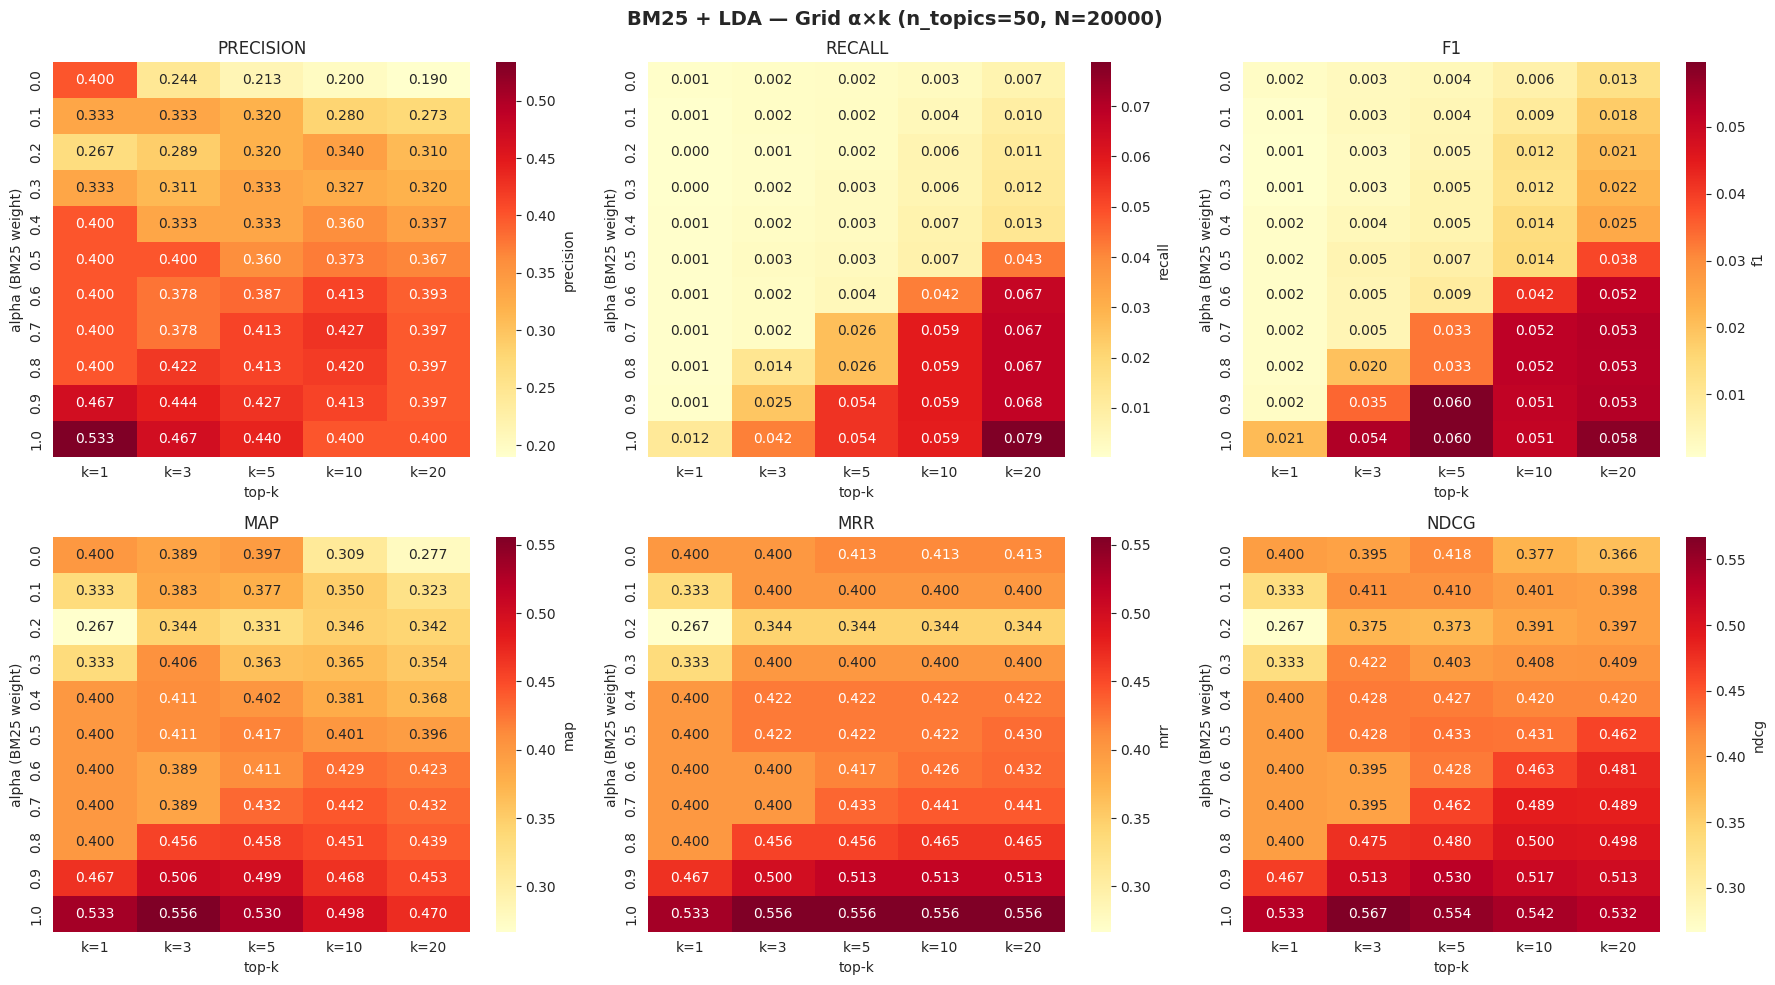

In [17]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle(f'BM25 + LDA — Grid α×k (n_topics={DEFAULT_N_TOPICS}, N={MAX_SAMPLES})', fontsize=14, fontweight='bold')
for ax, m in zip(axes.flat, METRIC_KEYS):
    sns.heatmap(grid_to_df(grid_results, m), annot=True, fmt='.3f', cmap='YlOrRd', ax=ax, cbar_kws={'label': m})
    ax.set_title(m.upper())
    ax.set_xlabel('top-k')
    ax.set_ylabel('alpha (BM25 weight)')
plt.tight_layout()
plt.show()

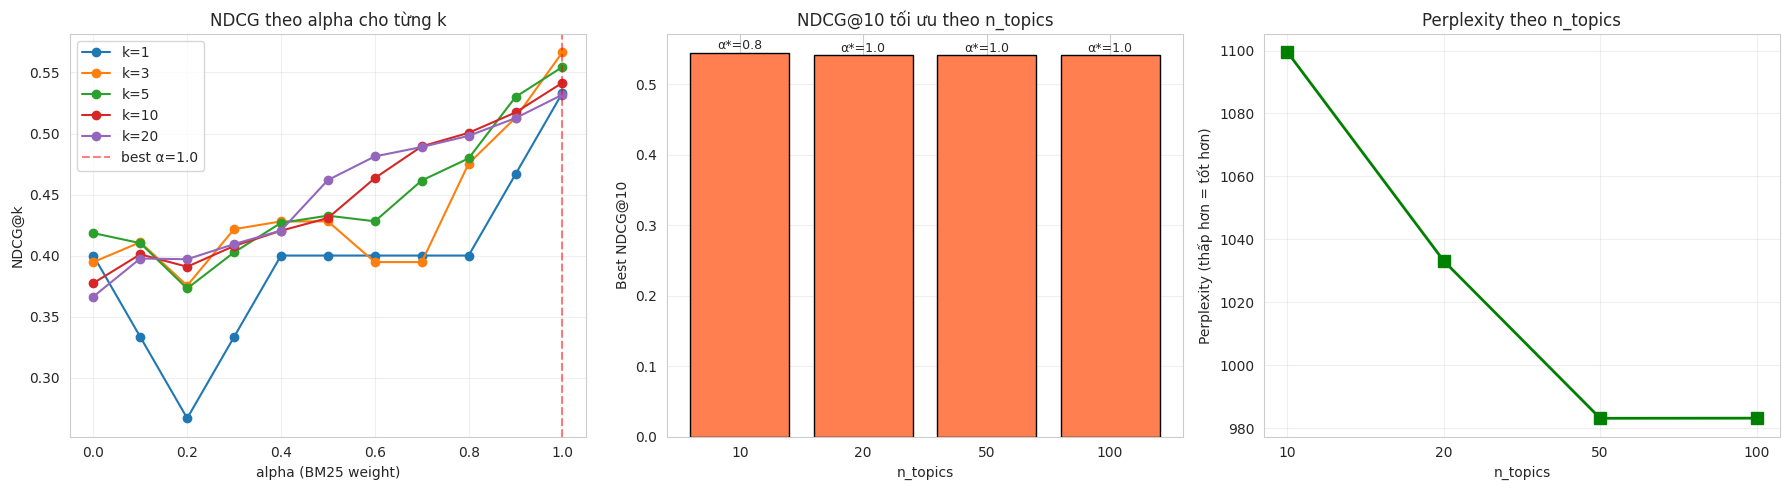

In [18]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

ax = axes[0]
for k in K_GRID:
    vals = [grid_results[a][k]['ndcg'] for a in ALPHA_GRID]
    ax.plot(ALPHA_GRID, vals, marker='o', label=f'k={k}')
ax.axvline(best_alpha, color='red', linestyle='--', alpha=0.5, label=f'best α={best_alpha}')
ax.set_xlabel('alpha (BM25 weight)'); ax.set_ylabel('NDCG@k')
ax.set_title('NDCG theo alpha cho từng k'); ax.legend(); ax.grid(True, alpha=0.3)

ax = axes[1]
ax.bar(ntopic_df.index.astype(str), ntopic_df['best_ndcg'], color='coral', edgecolor='black')
for i, (nt, row) in enumerate(ntopic_df.iterrows()):
    ax.text(i, row['best_ndcg'] + 0.005, f"α*={row['best_alpha']}", ha='center', fontsize=9)
ax.set_xlabel('n_topics'); ax.set_ylabel('Best NDCG@10')
ax.set_title('NDCG@10 tối ưu theo n_topics'); ax.grid(True, alpha=0.3, axis='y')

ax = axes[2]
ax.plot(ntopic_df.index.astype(str), ntopic_df['perplexity'], marker='s', linewidth=2, markersize=8, color='green')
ax.set_xlabel('n_topics'); ax.set_ylabel('Perplexity (thấp hơn = tốt hơn)')
ax.set_title('Perplexity theo n_topics'); ax.grid(True, alpha=0.3)

plt.tight_layout(); plt.show()

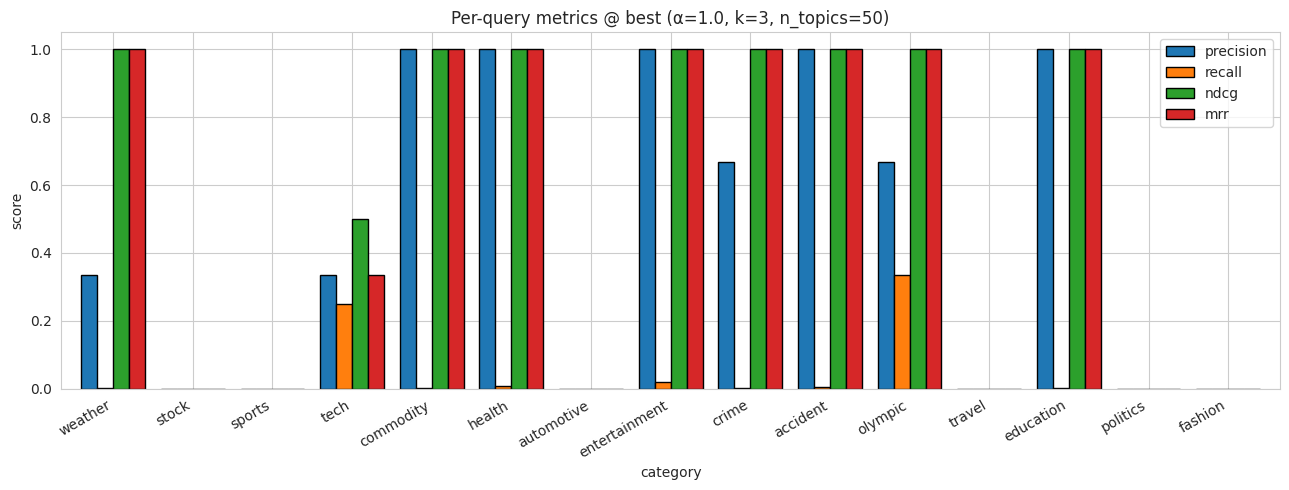

     category                               query  precision  recall     f1    map    mrr  ndcg
      weather   thời tiết mưa bão nhiệt độ dự báo     0.3333  0.0028 0.0056 1.0000 1.0000   1.0
        stock chứng khoán cổ phiếu thị trường đầu     0.0000  0.0000 0.0000 0.0000 0.0000   0.0
       sports  bóng đá việt nam cầu thủ đội tuyển     0.0000  0.0000 0.0000 0.0000 0.0000   0.0
         tech công nghệ AI trí tuệ nhân tạo máy h     0.3333  0.2500 0.2857 0.3333 0.3333   0.5
    commodity          giá vàng hôm nay tăng mạnh     1.0000  0.0012 0.0023 1.0000 1.0000   1.0
       health       dịch covid vaccine tiêm chủng     1.0000  0.0078 0.0154 1.0000 1.0000   1.0
   automotive       xe điện vinfast ô tô sản xuất     0.0000  0.0000 0.0000 0.0000 0.0000   0.0
entertainment        ca sĩ nhạc mới album âm nhạc     1.0000  0.0201 0.0395 1.0000 1.0000   1.0
        crime             tội phạm ma túy bắt giữ     0.6667  0.0006 0.0012 1.0000 1.0000   1.0
     accident          tai nạn giao thôn

In [19]:
rows = []
for q_idx, tq in enumerate(TEST_QUERIES):
    bm_n, sem_n = compute_query_scores(tq['query'], doc_topic_norm, lda_model)
    final = best_alpha * bm_n + (1.0 - best_alpha) * sem_n
    ranked = top_k_indices(final, best_k)
    m = query_metrics(ranked, RELEVANCE[q_idx], best_k)
    rows.append({'category': tq['category'], 'query': tq['query'][:35], **m})
per_query_df = pd.DataFrame(rows)

fig, ax = plt.subplots(figsize=(13, 5))
per_query_df.set_index('category')[['precision', 'recall', 'ndcg', 'mrr']].plot(
    kind='bar', ax=ax, width=0.8, edgecolor='black')
ax.set_title(f'Per-query metrics @ best (α={best_alpha}, k={best_k}, n_topics={DEFAULT_N_TOPICS})')
ax.set_ylabel('score'); ax.set_xlabel('category')
plt.xticks(rotation=30, ha='right'); plt.tight_layout(); plt.show()
print(per_query_df.round(4).to_string(index=False))

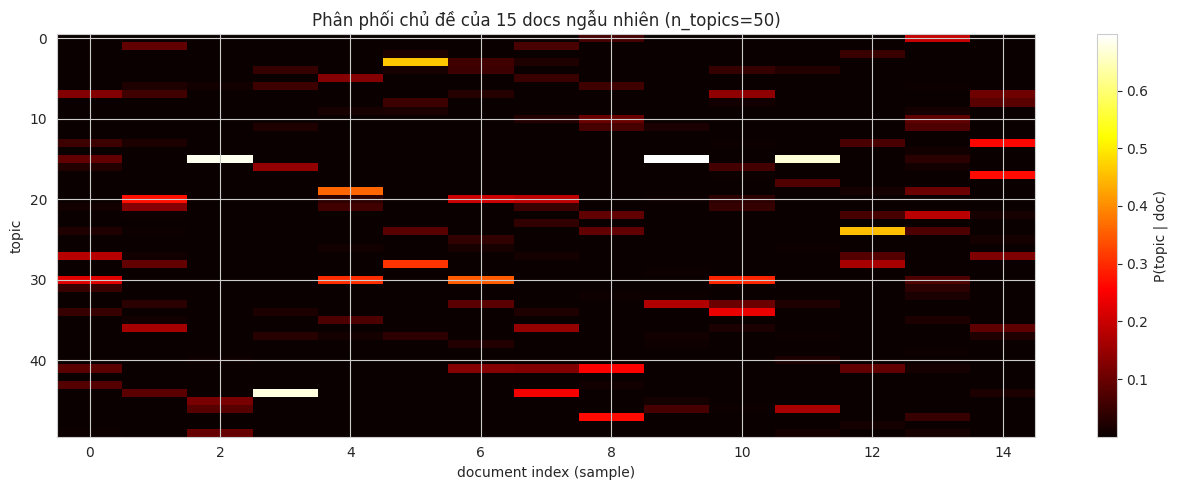

In [20]:
fig, ax = plt.subplots(figsize=(13, 5))
sample_ids = np.random.choice(len(doc_topic_dist), size=15, replace=False)
im = ax.imshow(doc_topic_dist[sample_ids].T, aspect='auto', cmap='hot', interpolation='nearest')
ax.set_xlabel('document index (sample)')
ax.set_ylabel('topic')
ax.set_title(f'Phân phối chủ đề của 15 docs ngẫu nhiên (n_topics={DEFAULT_N_TOPICS})')
plt.colorbar(im, ax=ax, label='P(topic | doc)')
plt.tight_layout()
plt.show()

## 12. LƯU MÔ HÌNH

In [21]:
MODEL_DIR = './saved_models'
os.makedirs(MODEL_DIR, exist_ok=True)
zip_path = os.path.join(MODEL_DIR, f'{MODEL_NAME}_models.zip')

artifacts = {
    'bm25_model.pkl':       bm25_model,
    'count_vectorizer.pkl': count_vectorizer,
    'lda_model.pkl':        lda_model,
    'doc_topic_dist.pkl':   doc_topic_dist,
    'tokenized_docs.pkl':   tokenized_docs,
    'documents.pkl':        documents,
    'titles.pkl':           titles,
    'urls.pkl':             urls,
    'grid_results.pkl':     grid_results,
    'config.pkl': {
        'model_name': MODEL_NAME, 'n_samples': MAX_SAMPLES,
        'best_alpha': best_alpha, 'best_k': best_k,
        'default_n_topics': DEFAULT_N_TOPICS,
    },
}

with zipfile.ZipFile(zip_path, 'w', zipfile.ZIP_DEFLATED) as zf:
    for name, obj in artifacts.items():
        joblib.dump(obj, name)
        zf.write(name, name)
        os.remove(name)
print(f'Saved {len(artifacts)} artifacts to {zip_path}')

Saved 10 artifacts to ./saved_models/lda_models.zip


## 13. DEMO TOP-K VỚI CẤU HÌNH TỐI ƯU

In [22]:
DEMO_QUERIES = ['thời tiết hôm nay', 'giá vàng thị trường', 'bóng đá việt nam', 'công nghệ trí tuệ nhân tạo']
for q in DEMO_QUERIES:
    indices, scores, details = search_hybrid(q, alpha=best_alpha, top_k=best_k)
    print(f'\n>>> "{q}" (α={best_alpha}, k={best_k})')
    for rank, (idx, score) in enumerate(zip(indices, scores), 1):
        bm = details['bm25_scores'].get(idx, 0.0)
        ld = details['lda_scores'].get(idx, 0.0)
        print(f'  {rank}. [{score:.3f}] BM25={bm:.3f} LDA={ld:.3f} | {titles[idx][:80]}')


>>> "thời tiết hôm nay" (α=1.0, k=3)
  1. [1.000] BM25=1.000 LDA=0.581 | Thời_tiết phức_tạp , trường_học ở TP. HCM được chủ_động cho học_sinh nghỉ
  2. [0.908] BM25=0.908 LDA=0.782 | Nhiều dự_báo khác nhau về đợt áp_thấp_nhiệt_đới trên Biển_Đông
  3. [0.869] BM25=0.869 LDA=0.248 | Mưa lớn kéo_dài , đêm chung_khảo HHVN phía Bắc có nguy_cơ chuyển địa_điểm

>>> "giá vàng thị trường" (α=1.0, k=3)
  1. [1.000] BM25=1.000 LDA=1.000 | Giá vàng tăng gần 41 triệu đồng / lượng giữa căng_thẳng Mỹ - Trung
  2. [0.937] BM25=0.937 LDA=0.698 | Dầu , vàng khó bị ảnh_hưởng nếu Syria không căng
  3. [0.840] BM25=0.840 LDA=0.487 | Tiết_lộ lý_do cựu PCT thường_trực TP. Hồ_Chí_Minh_Nguyễn_Thành_Tài nhúng chàm

>>> "bóng đá việt nam" (α=1.0, k=3)
  1. [1.000] BM25=1.000 LDA=0.703 | Thủ_tướng khen việc tổ_chức lễ đón U23 Việt_Nam
  2. [0.988] BM25=0.988 LDA=0.711 | Thủ_tướng gửi thư chúc_mừng đội_tuyển U -23 Việt_Nam
  3. [0.966] BM25=0.966 LDA=0.553 | Mỹ_Tâm " phá đảo thế_giới ảo " với màn ra đường " đi bã